#1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


 2. Load Dataset

In [ ]:
df = pd.read_csv('auto-mpg.csv')

#  Basic Exploration

In [ ]:
print("First 5 rows:\n", df.head())

First 5 rows:
     mpg  cylinders  displacement horsepower  weight  acceleration  model year  \
0  18.0          8         307.0        130    3504          12.0          70   
1  15.0          8         350.0        165    3693          11.5          70   
2  18.0          8         318.0        150    3436          11.0          70   
3  16.0          8         304.0        150    3433          12.0          70   
4  17.0          8         302.0        140    3449          10.5          70   

   origin                   car name  
0       1  chevrolet chevelle malibu  
1       1          buick skylark 320  
2       1         plymouth satellite  
3       1              amc rebel sst  
4       1                ford torino  


In [ ]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64


In [ ]:
print("\nStatistical Summary:\n", df.describe())


Statistical Summary:
               mpg   cylinders  displacement       weight  acceleration  \
count  398.000000  398.000000    398.000000   398.000000    398.000000   
mean    23.514573    5.454774    193.425879  2970.424623     15.568090   
std      7.815984    1.701004    104.269838   846.841774      2.757689   
min      9.000000    3.000000     68.000000  1613.000000      8.000000   
25%     17.500000    4.000000    104.250000  2223.750000     13.825000   
50%     23.000000    4.000000    148.500000  2803.500000     15.500000   
75%     29.000000    8.000000    262.000000  3608.000000     17.175000   
max     46.600000    8.000000    455.000000  5140.000000     24.800000   

       model year      origin  
count  398.000000  398.000000  
mean    76.010050    1.572864  
std      3.697627    0.802055  
min     70.000000    1.000000  
25%     73.000000    1.000000  
50%     76.000000    1.000000  
75%     79.000000    2.000000  
max     82.000000    3.000000  


#4. Data Cleaning

In [ ]:
df.replace('?', np.nan, inplace=True)
df['horsepower'] = pd.to_numeric(df['horsepower'])
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# # 5. Feature Engineering

In [ ]:
# Extract brand from car name
df['brand'] = df['car name'].apply(lambda x: x.split()[0])

In [ ]:

# One-hot encoding
df = pd.get_dummies(df, columns=['brand'], drop_first=True)

In [ ]:
df['power_to_weight'] = df['horsepower'] / df['weight']

In [ ]:
df['car_age'] = df['model year'].max() - df['model year']

#  5. EDA (Exploratory Data Analysis)

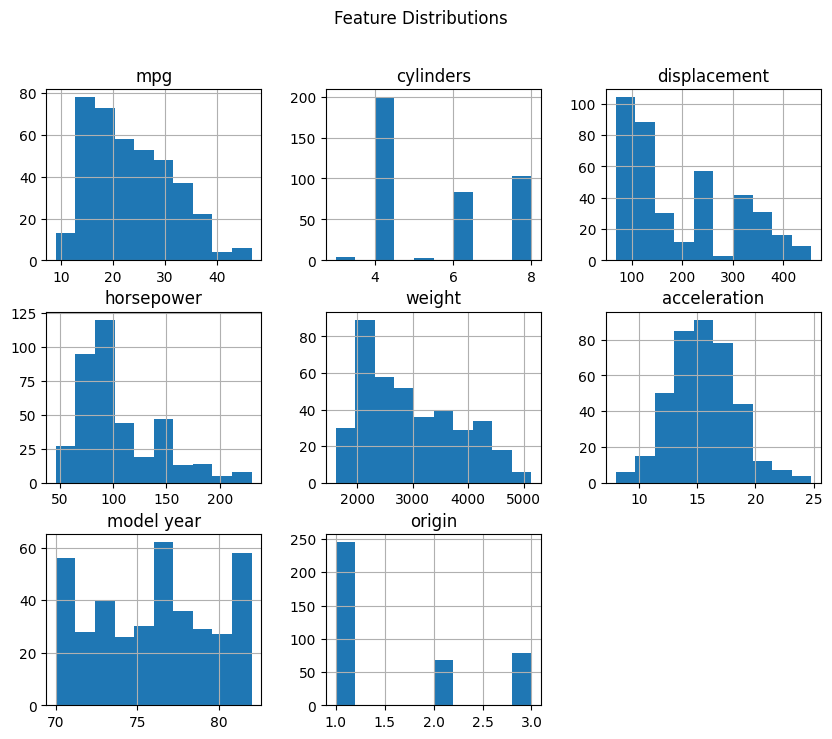

In [ ]:
df.hist(figsize=(10,8))
plt.suptitle("Feature Distributions")
plt.show()

In [ ]:
sns.pairplot(df)
plt.show()

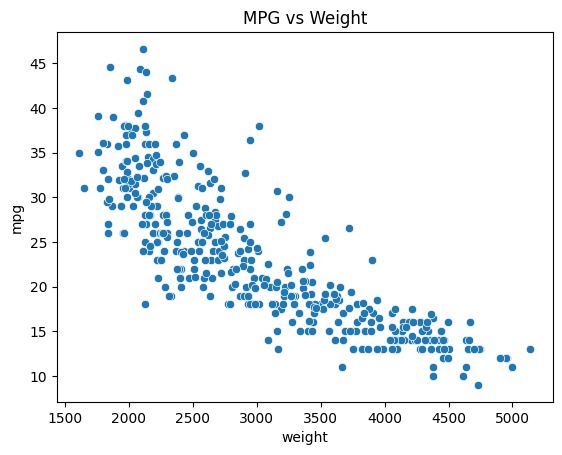

In [ ]:
# Scatter Plot
sns.scatterplot(x='weight', y='mpg', data=df)
plt.title("MPG vs Weight")
plt.show()

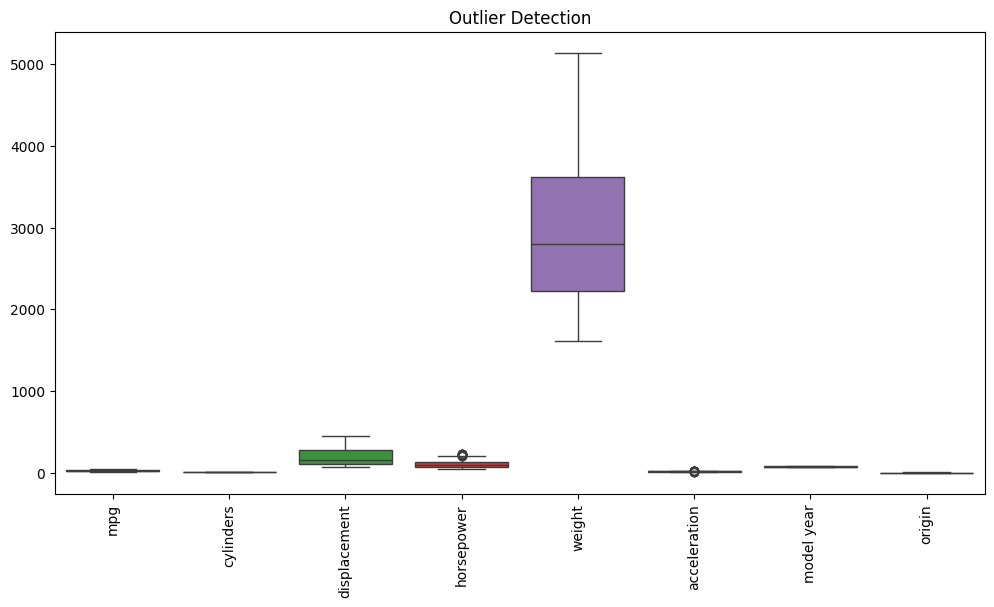

In [ ]:
# Boxplot (Outliers)
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

# 7. Outlier Removal (IQR Method)

In [ ]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

# Calculate IQR
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Filter out outliers
df = df[~((numeric_df < (Q1 - 1.5 * IQR)) |
          (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
mask = ~((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
df = df[mask]

# 7. Feature Selection

In [ ]:
X = df.drop(['mpg', 'car name'], axis=1)

In [ ]:
y = df['mpg']

In [ ]:
print("\nFeatures used:\n", X.columns)


Features used:
 Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model year', 'origin', 'brand_audi', 'brand_bmw', 'brand_buick',
       'brand_cadillac', 'brand_capri', 'brand_chevroelt', 'brand_chevrolet',
       'brand_chevy', 'brand_chrysler', 'brand_datsun', 'brand_dodge',
       'brand_fiat', 'brand_ford', 'brand_hi', 'brand_honda', 'brand_maxda',
       'brand_mazda', 'brand_mercedes', 'brand_mercedes-benz', 'brand_mercury',
       'brand_nissan', 'brand_oldsmobile', 'brand_opel', 'brand_peugeot',
       'brand_plymouth', 'brand_pontiac', 'brand_renault', 'brand_saab',
       'brand_subaru', 'brand_toyota', 'brand_toyouta', 'brand_triumph',
       'brand_vokswagen', 'brand_volkswagen', 'brand_volvo', 'brand_vw'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#  9. Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# 10. Model Selection & Training

In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

RandomForestRegressor()

# 11. Model Evaluation

In [ ]:

def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)

# Evaluation
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)




Linear Regression Performance:
RMSE: 3.675296454554176
R2 Score: 0.7777249170494136

Random Forest Performance:
RMSE: 3.1516531604596985
R2 Score: 0.8365507754992593


In [ ]:
y_pred_lr

array([27.42481853, 18.61298393, 21.5446704 , 29.5518765 , 11.58147628,
       32.28827168, 10.79826769,  9.32328403, 13.20592422, 27.43946905,
       24.47497237, 25.72074626, 22.63142945, 12.03608327, 13.17178383,
       17.32490271, 31.8648038 , 34.10661827, 22.30396899, 18.1960741 ,
       18.01195934, 16.93454948, 14.52873432, 35.41278095, 30.44510337,
       29.45639093, 28.91217403, 15.0360391 , 23.54742428, 27.75904236,
       16.42549746, 19.73143955, 30.35151962, 35.69652569, 27.47077454,
       15.54681234, 21.26912479, 18.13382086, 35.6274553 , 22.05710948,
       21.23005058, 27.03029707,  7.34590426, 29.31840941, 30.5354734 ,
       34.61643032, 25.04955216, 22.71330556, 15.13395011, 25.43958807,
       21.63356781, 24.22303823, 27.19881884, 29.0140031 , 35.08753943,
       27.68652927, 28.47789456, 12.79602327, 31.1537701 , 12.98735095,
       29.1715527 , 31.41828973, 12.44445051, 24.98414252, 27.38594695,
       12.48957615, 29.11131866, 32.02789169, 25.71728849, 20.83

In [ ]:
y_pred_rf

array([25.781, 19.244, 24.354, 27.963, 15.135, 31.47 , 13.57 , 13.947,
       16.42 , 27.09 , 26.242, 28.935, 19.456, 12.76 , 14.995, 17.246,
       33.54 , 35.845, 24.2  , 20.631, 20.68 , 15.448, 14.455, 36.547,
       29.068, 29.118, 24.213, 15.16 , 24.59 , 26.898, 18.825, 17.441,
       30.64 , 36.828, 24.049, 16.929, 20.793, 18.641, 35.058, 21.1  ,
       18.296, 26.278, 12.865, 29.688, 30.895, 34.301, 25.938, 26.292,
       16.612, 25.409, 20.057, 22.73 , 26.169, 28.275, 29.98 , 28.086,
       28.455, 16.904, 35.254, 14.23 , 30.429, 33.821, 14.31 , 27.1  ,
       30.311, 14.472, 37.741, 31.007, 26.684, 19.344, 23.   , 33.267,
       28.789])

In [ ]:
# Evaluation function
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Performance:")
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2 Score:", r2_score(y_true, y_pred))

evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)



Linear Regression Performance:
RMSE: 3.675296454554176
R2 Score: 0.7777249170494136

Random Forest Performance:
RMSE: 3.1516531604596985
R2 Score: 0.8365507754992593


#  12. Model Comparison Plot

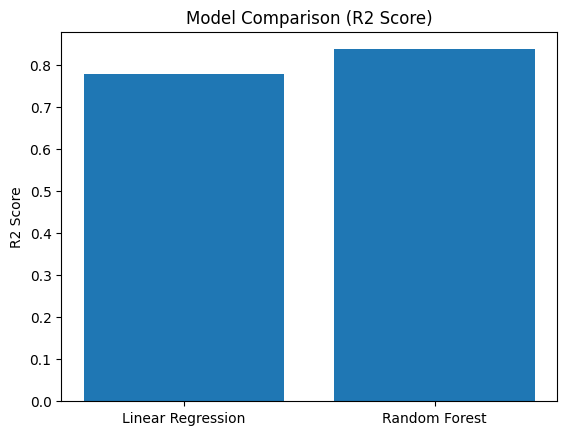

In [ ]:
models = ['Linear Regression', 'Random Forest']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf)
]

plt.bar(models, r2_scores)
plt.title("Model Comparison (R2 Score)")
plt.ylabel("R2 Score")
plt.show()